<a href="https://colab.research.google.com/github/pranathiperii/WHRadjBMI-adipose-regulatory-analysis/blob/main/WHRadjBMI_mesothelial_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mini-project 4 — Systematic mesothelial gene discovery in WHR GWAS loci

## Aim
To identify which WHRadjBMI GWAS candidate genes show mesothelial-enriched
expression in human adipose single-cell data, extending the manual finding
from mini-project 3 (RFLNA in mesothelial cells) to the full set of
genome-wide significant loci.

## Hypothesis
RFLNA was found to be expressed predominantly in mesothelial cells rather
than adipocytes in mini-project 3. If this reflects a broader biological
pattern, other WHR GWAS genes may also show mesothelial-enriched expression
and have been misclassified as adipose genes in bulk tissue studies.

## Data sources
- WHRadjBMI GWAS associations — GWAS Catalog (curated in mini-project 1)
- Human adipose single-cell atlas — Emont et al. 2022, Nature
  (A Single-Cell Atlas of Human White Adipose Tissue, 166,149 cells)
  accessed via CellxGene

In [2]:
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.colab import files

# load single-cell dataset
print("Loading single-cell dataset...")
adata = sc.read_h5ad('emont2022_adipose.h5ad')
print(f"Dataset loaded: {adata.n_obs} cells, {adata.n_vars} genes")

# build gene symbol conversion dictionaries
symbol_to_ensembl = dict(zip(adata.var['feature_name'], adata.var.index))
ensembl_to_symbol = dict(zip(adata.var.index, adata.var['feature_name']))
print(f"Gene conversion table built: {len(symbol_to_ensembl)} genes")

# upload and load GWAS file
print("\nPlease upload your GWAS Catalog TSV file...")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

gwas_raw = pd.read_csv(filename, sep='\t', low_memory=False, encoding='latin-1')
gwas_raw['P-VALUE'] = pd.to_numeric(gwas_raw['P-VALUE'], errors='coerce')

gwas_filtered = gwas_raw[
    (gwas_raw['P-VALUE'] < 5e-8) &
    (gwas_raw['MAPPED_TRAIT'] == 'BMI-adjusted waist-hip ratio')
].copy()
gwas_filtered = gwas_filtered.sort_values('P-VALUE')
gwas_filtered = gwas_filtered.drop_duplicates(subset='SNPS', keep='first')
gwas_filtered = gwas_filtered.reset_index(drop=True)
print(f"GWAS associations filtered: {len(gwas_filtered)}")

# extract GWAS genes
all_genes = []
for entry in gwas_filtered['MAPPED_GENE'].dropna():
    genes = [g.strip() for g in entry.replace(',', ' ').replace('-', ' ').split()]
    all_genes.extend(genes)
all_genes = list(set(all_genes))

genes_in_dataset = [g for g in all_genes if g in symbol_to_ensembl]
print(f"GWAS genes found in dataset: {len(genes_in_dataset)} out of {len(all_genes)}")

# subset dataset to GWAS genes
gwas_ensembl_ids = [symbol_to_ensembl[g] for g in genes_in_dataset]
adata_gwas = adata[:, gwas_ensembl_ids].copy()
adata_gwas.var['gene_symbol'] = [ensembl_to_symbol[e] for e in adata_gwas.var.index]

print(f"\nSetup complete.")
print(f"Working with {adata_gwas.n_vars} GWAS genes across {adata_gwas.n_obs} cells")
print(f"\nCell types in dataset:")
print(adata.obs['cell_type'].value_counts())

Loading single-cell dataset...
Dataset loaded: 166149 cells, 28101 genes
Gene conversion table built: 28098 genes

Please upload your GWAS Catalog TSV file...


Saving gwas-association-downloaded_2026-03-18-EFO_0004343-withChildTraits.tsv to gwas-association-downloaded_2026-03-18-EFO_0004343-withChildTraits (2).tsv
GWAS associations filtered: 3942
GWAS genes found in dataset: 1155 out of 1505

Setup complete.
Working with 1155 GWAS genes across 166149 cells

Cell types in dataset:
cell_type
preadipocyte                            52482
mesothelial cell                        30482
adipocyte                               25871
macrophage                              18312
endothelial cell                        15483
T cell                                   7194
endothelial cell of lymphatic vessel     2901
smooth muscle cell                       2886
immature NK T cell                       2629
dendritic cell                           2441
monocyte                                 1949
pericyte                                 1464
mast cell                                1168
B cell                                    429
stromal cell of endom

In [3]:
# calculate mean expression per cell type for all GWAS genes
print("Calculating mean expression per cell type...")

# add cell type info to the gwas subset
adata_gwas.obs['cell_type'] = adata.obs['cell_type']
adata_gwas.obs['fat_type'] = adata.obs['fat_type']

# calculate mean expression per cell type
import scipy.sparse as sp

cell_type_means = {}

for ct in adata.obs['cell_type'].unique():
    mask = adata_gwas.obs['cell_type'] == ct
    subset = adata_gwas[mask]

    if sp.issparse(subset.X):
        means = np.array(subset.X.mean(axis=0)).flatten()
    else:
        means = subset.X.mean(axis=0)

    cell_type_means[ct] = means

# build a dataframe — rows are genes, columns are cell types
mean_expr_df = pd.DataFrame(
    cell_type_means,
    index=adata_gwas.var['gene_symbol']
)

print(f"Mean expression matrix shape: {mean_expr_df.shape}")
print(f"Rows = genes, Columns = cell types")
print(mean_expr_df.head())

Calculating mean expression per cell type...
Mean expression matrix shape: (1155, 16)
Rows = genes, Columns = cell types
             preadipocyte  mesothelial cell  pericyte  adipocyte  macrophage  \
gene_symbol                                                                    
ITGA9            0.380815          0.211063  0.167851   0.278196    0.645584   
ITGB3            0.026569          0.004409  0.006628   0.001383    0.002294   
SHC1             0.086965          0.073590  0.093713   0.216907    0.046899   
TM6SF2           0.002574          0.000000  0.000000   0.000036    0.000404   
WDR35            0.202860          0.366277  0.128899   0.143937    0.083254   

             endothelial cell  endothelial cell of lymphatic vessel  monocyte  \
gene_symbol                                                                     
ITGA9                0.648774                              1.619287  0.090870   
ITGB3                0.017802                              0.015395  0.0035

In [4]:
# calculate mesothelial enrichment score for each gene
# enrichment = mean expression in mesothelial cells / mean expression across all other cell types

print("Calculating mesothelial enrichment scores...")

# mean expression in mesothelial cells
meso_expr = mean_expr_df['mesothelial cell']

# mean expression across all non-mesothelial cell types
other_cols = [c for c in mean_expr_df.columns if c != 'mesothelial cell']
other_expr = mean_expr_df[other_cols].mean(axis=1)

# enrichment score — add small value to avoid division by zero
enrichment_score = meso_expr / (other_expr + 1e-6)

# also calculate what fraction of total expression is in mesothelial cells
total_expr = mean_expr_df.sum(axis=1)
meso_fraction = meso_expr / (total_expr + 1e-6)

# build results dataframe
results = pd.DataFrame({
    'gene': mean_expr_df.index,
    'meso_mean_expr': meso_expr.values,
    'other_mean_expr': other_expr.values,
    'meso_enrichment_score': enrichment_score.values,
    'meso_fraction_of_total': meso_fraction.values
})

# filter to genes with detectable expression in mesothelial cells
results = results[results['meso_mean_expr'] > 0.01].copy()

# sort by enrichment score
results = results.sort_values('meso_enrichment_score', ascending=False)
results = results.reset_index(drop=True)

print(f"Genes with detectable mesothelial expression: {len(results)}")
print(f"\nTop 20 most mesothelially enriched WHR GWAS genes:")
print(results.head(20).to_string())

# save
results.to_csv('WHRadjBMI_mesothelial_enrichment.csv', index=False)
print("\nSaved as WHRadjBMI_mesothelial_enrichment.csv")

Calculating mesothelial enrichment scores...
Genes with detectable mesothelial expression: 856

Top 20 most mesothelially enriched WHR GWAS genes:
         gene  meso_mean_expr  other_mean_expr  meso_enrichment_score  meso_fraction_of_total
0        SCEL        0.586626         0.016647              35.237217                0.701428
1   LINC01638        0.043576         0.001509              28.853128                0.658088
2      CASC20        0.234964         0.010538              22.294712                0.597820
3     HSD17B6        0.409200         0.023647              17.304096                0.535672
4   LINC01829        0.091470         0.006395              14.301090                0.488110
5        COBL        0.683496         0.050379              13.566858                0.474921
6         WT1        1.172706         0.094749              12.376797                0.452093
7        HHIP        0.616613         0.051203              12.042238                0.445317
8   LIN

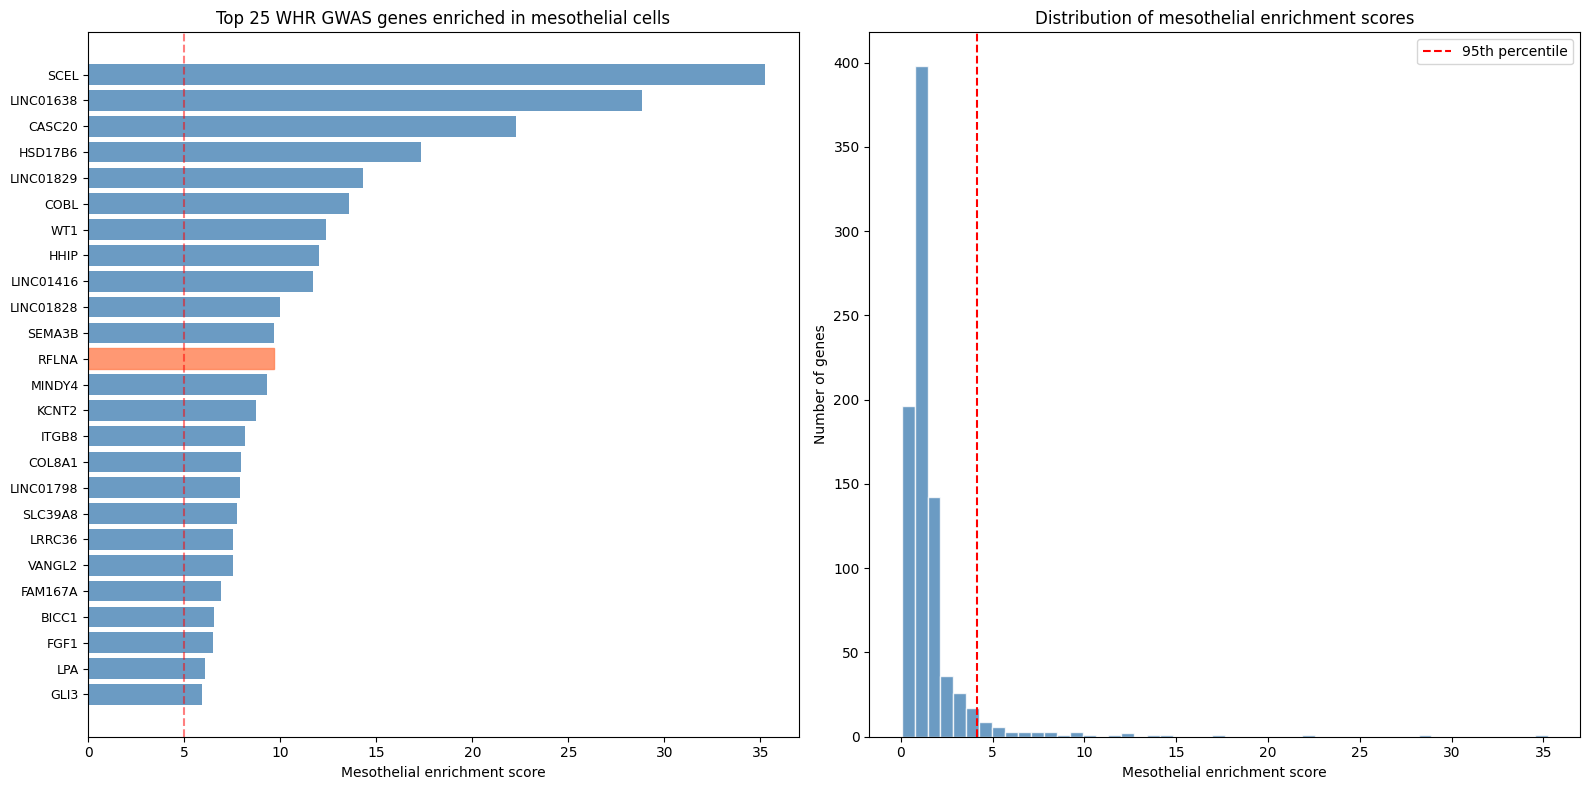

Figure saved


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# plot 1 — top 25 enriched genes
top25 = results.head(25)

bars = axes[0].barh(
    range(len(top25)),
    top25['meso_enrichment_score'],
    color='steelblue',
    alpha=0.8
)

# highlight RFLNA in coral
for i, gene in enumerate(top25['gene']):
    if gene == 'RFLNA':
        bars[i].set_color('coral')

axes[0].set_yticks(range(len(top25)))
axes[0].set_yticklabels(top25['gene'], fontsize=9)
axes[0].invert_yaxis()
axes[0].set_xlabel('Mesothelial enrichment score')
axes[0].set_title('Top 25 WHR GWAS genes enriched in mesothelial cells')
axes[0].axvline(x=5, color='red', linestyle='dashed', alpha=0.5)

# plot 2 — distribution of all enrichment scores
axes[1].hist(
    results['meso_enrichment_score'],
    bins=50,
    color='steelblue',
    alpha=0.8,
    edgecolor='white'
)
axes[1].axvline(
    x=results['meso_enrichment_score'].quantile(0.95),
    color='red',
    linestyle='dashed',
    label='95th percentile'
)
axes[1].set_xlabel('Mesothelial enrichment score')
axes[1].set_ylabel('Number of genes')
axes[1].set_title('Distribution of mesothelial enrichment scores')
axes[1].legend()

plt.tight_layout()
plt.savefig('mesothelial_enrichment.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved")

In [7]:
# look at the top hits more carefully
# add some biological context

top_hits = results.head(25).copy()

# check which are protein coding vs lncRNA
gene_biotype = dict(zip(adata.var['feature_name'], adata.var['feature_type']))
top_hits['biotype'] = top_hits['gene'].map(gene_biotype)

print("Top 25 mesothelially enriched WHR GWAS genes with biotype:")
print(top_hits[['gene', 'meso_enrichment_score',
                 'meso_fraction_of_total', 'biotype']].to_string())

print(f"\nBiotype breakdown:")
print(top_hits['biotype'].value_counts())

# how many of the top 5% are protein coding
top5pct = results[results['meso_enrichment_score'] >=
                  results['meso_enrichment_score'].quantile(0.95)]
print(f"\nGenes above 95th percentile: {len(top5pct)}")
print(f"Biotype breakdown above 95th percentile:")
top5pct_biotype = top5pct['gene'].map(gene_biotype)
print(top5pct_biotype.value_counts())

# save top hits
top_hits.to_csv('WHRadjBMI_mesothelial_top_hits.csv', index=False)
print("\nSaved top hits as WHRadjBMI_mesothelial_top_hits.csv")

Top 25 mesothelially enriched WHR GWAS genes with biotype:
         gene  meso_enrichment_score  meso_fraction_of_total         biotype
0        SCEL              35.237217                0.701428  protein_coding
1   LINC01638              28.853128                0.658088          lncRNA
2      CASC20              22.294712                0.597820          lncRNA
3     HSD17B6              17.304096                0.535672  protein_coding
4   LINC01829              14.301090                0.488110          lncRNA
5        COBL              13.566858                0.474921  protein_coding
6         WT1              12.376797                0.452093  protein_coding
7        HHIP              12.042238                0.445317  protein_coding
8   LINC01416              11.688260                0.437972          lncRNA
9   LINC01828               9.998126                0.399966          lncRNA
10     SEMA3B               9.694058                0.392571  protein_coding
11      RFLNA    

Enrichment tier breakdown:
enrichment_tier
low          713
moderate     111
high          23
very high      9
Name: count, dtype: int64


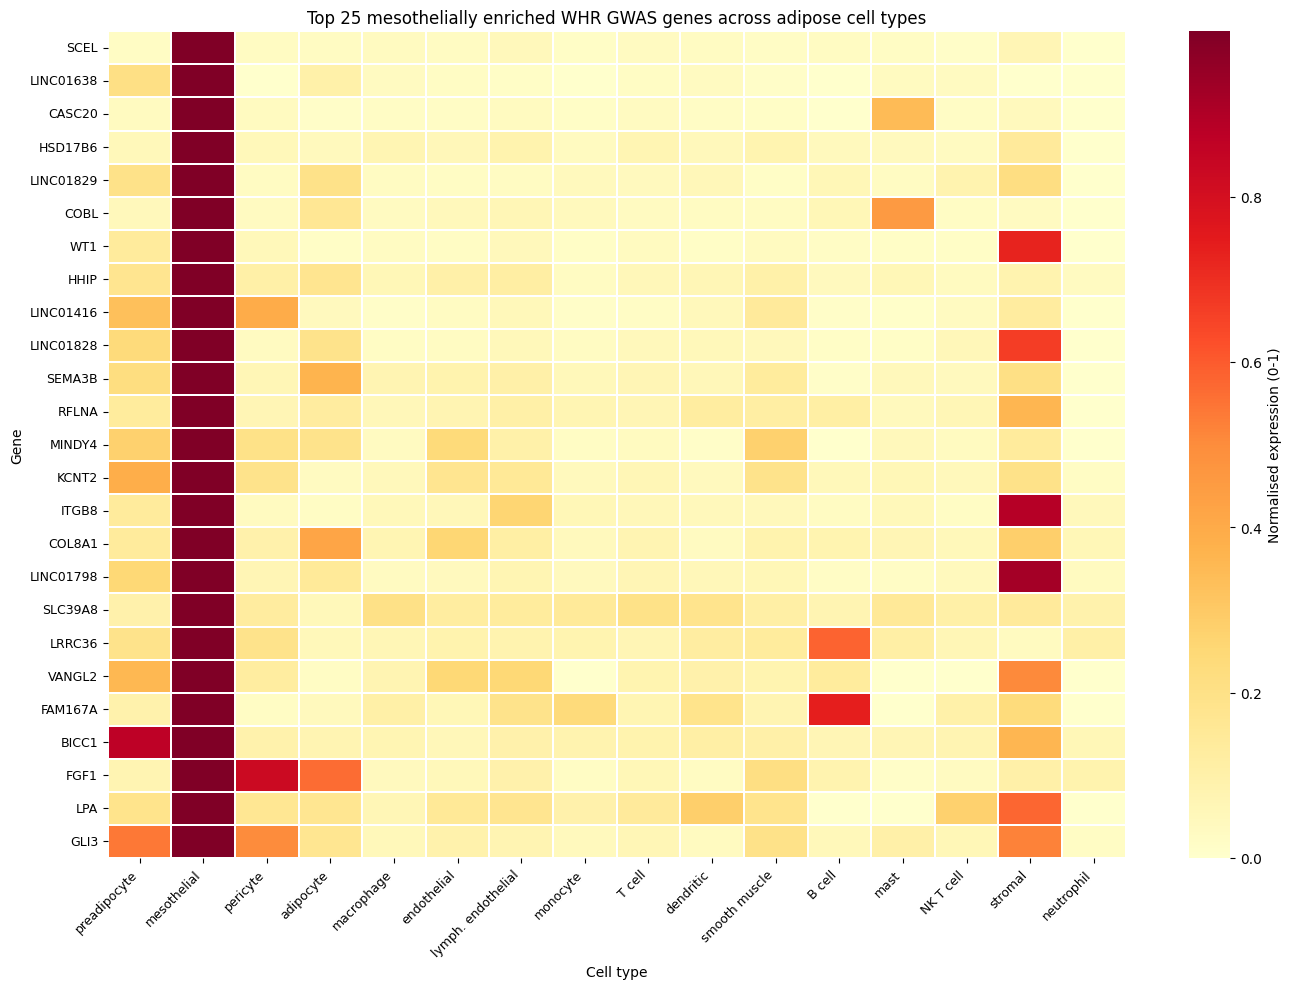

Heatmap saved

Mini-project 4 complete
Total WHR GWAS genes analysed: 856
Genes with high or very high mesothelial enrichment: 32

Top 5 hits: ['SCEL', 'LINC01638', 'CASC20', 'HSD17B6', 'LINC01829']
These genes have likely been misclassified as adipose genes in bulk tissue studies


In [9]:
# final summary — classify all genes into enrichment tiers
results['enrichment_tier'] = pd.cut(
    results['meso_enrichment_score'],
    bins=[0, 2, 5, 10, 100],
    labels=['low', 'moderate', 'high', 'very high']
)

print("Enrichment tier breakdown:")
print(results['enrichment_tier'].value_counts())

# heatmap of top 25 genes across all cell types
top25_genes = results.head(25)['gene'].tolist()

heatmap_data = mean_expr_df.loc[top25_genes].copy()

# shorten column names
col_rename = {
    'endothelial cell': 'endothelial',
    'endothelial cell of lymphatic vessel': 'lymph. endothelial',
    'mesothelial cell': 'mesothelial',
    'smooth muscle cell': 'smooth muscle',
    'immature NK T cell': 'NK T cell',
    'stromal cell of endometrium': 'stromal',
    'dendritic cell': 'dendritic',
    'mast cell': 'mast',
    'B cell': 'B cell',
    'T cell': 'T cell'
}
heatmap_data = heatmap_data.rename(columns=col_rename)

# normalise each row to max
heatmap_norm = heatmap_data.div(heatmap_data.max(axis=1) + 1e-6, axis=0)

plt.figure(figsize=(14, 10))
sns.heatmap(
    heatmap_norm,
    cmap='YlOrRd',
    xticklabels=True,
    yticklabels=True,
    cbar_kws={'label': 'Normalised expression (0-1)'},
    linewidths=0.3,
    linecolor='white'
)
plt.title('Top 25 mesothelially enriched WHR GWAS genes across adipose cell types')
plt.xlabel('Cell type')
plt.ylabel('Gene')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('mesothelial_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap saved")

# final numbers
high_enriched = results[results['enrichment_tier'].isin(['high', 'very high'])]
print(f"\nMini-project 4 complete")
print(f"Total WHR GWAS genes analysed: {len(results)}")
print(f"Genes with high or very high mesothelial enrichment: {len(high_enriched)}")
print(f"\nTop 5 hits: {results.head(5)['gene'].tolist()}")
print("These genes have likely been misclassified as adipose genes in bulk tissue studies")